# Algorithm comparison for reviewer response

This notebook compares four algorithms on a small set of representative feature sets.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    GradientBoostingClassifier,
    GradientBoostingRegressor,
    HistGradientBoostingClassifier,
    HistGradientBoostingRegressor,
    RandomForestClassifier,
    RandomForestRegressor,
)
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    r2_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler

plt.style.use("default")
sns.set_theme(style="whitegrid")

In [2]:
dataset = "./2025 08 26_DF extended.xlsx"
df = pd.read_excel(dataset, sheet_name="updated_data")
df.shape

(244, 64)

In [3]:
feature_sets = {
    'A': ["T", "F", "ΔHc", 'K_Power_steady', 'n_Power_steady', 'η*', 'delta_η*', 'SM', 'tan_delta'],
    'B': ["T", "F", "T5", "WL_Tp", "ΔHc", 'K_Power_steady', 'n_Power_steady', 'η*', 'delta_η*', 'SM', 'tan_delta'],
    'C': ["T", "F", "T5", "WL_Tp", "ΔHc", 'K_Power_steady', 'n_Power_steady'],
    'D': ["T", "F", "T5", "WL_Tp", "ΔHc", 'eta0_Carreau_steady', 'eta_inf_Carreau_steady', 'L_Carreau_steady', 'n_Carreau_steady'],
    'E': ["T", "F", "T5", "WL_Tp", "ΔHc", 'K_Power_capillary', 'n_Power_capillary'],
    'F': ["T", "F", "T5", "WL_Tp", "ΔHc", 'eta0_Carreau_capillary', 'eta_inf_Carreau_capillary', 'L_Carreau_capillary', 'n_Carreau_capillary'],
    'X': ["T", "F", 'eta0_Carreau_capillary', 'eta_inf_Carreau_capillary', 'L_Carreau_capillary', 'n_Carreau_capillary'],
    'G': ["T", "F", "T5", "WL_Tp", "ΔHc", 'eta0_Carreau-Yasuda_capillary', 'eta_inf_Carreau-Yasuda_capillary', 
          'L_Carreau-Yasuda_capillary', 'n_Carreau-Yasuda_capillary', 'a_Carreau-Yasuda_capillary'],
    'H': ["T", "F"]
}

classification_sets = ["X", "F"]
regression_sets = ["X", "G"]
ra_regression_sets = ["X", "A", "B"]

In [4]:
bins = [-1.0, -0.60, -0.105, 0.11, 0.6]
labels = ["Not printable", "Under-extruded", "Best", "Over-extruded"]

df = df.copy()
df["Class"] = pd.cut(df["ΔW"], bins=bins, labels=labels, include_lowest=True)
df_best = df[(df["ΔW"] >= -0.105) & (df["ΔW"] < 0.11)].copy()

print("Classification dataset:", df.shape)
print(df["Class"].value_counts())
print("\nRegression dataset (best region only):", df_best.shape)

Classification dataset: (244, 65)
Class
Not printable     69
Over-extruded     63
Best              57
Under-extruded    55
Name: count, dtype: int64

Regression dataset (best region only): (57, 65)


## Model definitions

The same split strategy is used across all algorithms within each task. Scaling is applied through a pipeline for consistency across models.

In [5]:
classification_models = {
    "LogisticRegression": {
        "pipeline": Pipeline([
            ("scaler", MinMaxScaler()),
            ("model", LogisticRegression(max_iter=5000, class_weight="balanced", random_state=42)),
        ]),
        "param_grid": {
            "model__C": [0.1, 1.0, 10.0],
            "model__solver": ["lbfgs"],
        },
    },
    "RandomForest": {
        "pipeline": Pipeline([
            ("scaler", MinMaxScaler()),
            ("model", RandomForestClassifier(class_weight="balanced", random_state=42)),
        ]),
        "param_grid": {
            "model__n_estimators": [100, 250, 500],
            "model__max_depth": [5, 8, 12],
            "model__min_samples_split": [2, 5],
            "model__min_samples_leaf": [1, 2],
            "model__max_features": ["sqrt", None],
        },
    },
    "GradientBoosting": {
        "pipeline": Pipeline([
            ("scaler", MinMaxScaler()),
            ("model", GradientBoostingClassifier(random_state=42)),
        ]),
        "param_grid": {
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.03, 0.1],
            "model__max_depth": [2, 3],
        },
    },
    "HistGradientBoosting": {
        "pipeline": Pipeline([
            ("scaler", MinMaxScaler()),
            ("model", HistGradientBoostingClassifier(random_state=42)),
        ]),
        "param_grid": {
            "model__learning_rate": [0.03, 0.1],
            "model__max_depth": [3, 5, None],
            "model__max_iter": [100, 200],
            "model__min_samples_leaf": [10, 20],
        },
    },
}

regression_models = {
    "Ridge": {
        "pipeline": Pipeline([
            ("scaler", MinMaxScaler()),
            ("model", Ridge()),
        ]),
        "param_grid": {
            "model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0],
        },
    },
    "RandomForest": {
        "pipeline": Pipeline([
            ("scaler", MinMaxScaler()),
            ("model", RandomForestRegressor(random_state=42)),
        ]),
        "param_grid": {
            "model__n_estimators": [100, 250, 500],
            "model__max_depth": [4, 6, 8, 12],
            "model__min_samples_split": [2, 5],
            "model__min_samples_leaf": [1, 2],
            "model__max_features": ["sqrt", None],
        },
    },
    "GradientBoosting": {
        "pipeline": Pipeline([
            ("scaler", MinMaxScaler()),
            ("model", GradientBoostingRegressor(random_state=42)),
        ]),
        "param_grid": {
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.03, 0.1],
            "model__max_depth": [2, 3],
        },
    },
    "HistGradientBoosting": {
        "pipeline": Pipeline([
            ("scaler", MinMaxScaler()),
            ("model", HistGradientBoostingRegressor(random_state=42)),
        ]),
        "param_grid": {
            "model__learning_rate": [0.03, 0.1],
            "model__max_depth": [3, 5, None],
            "model__max_iter": [100, 200],
            "model__min_samples_leaf": [5, 10],
        },
    },
}

In [6]:
def run_classification_benchmark(df, feature_set_name, models, random_state=42):
    features = feature_sets[feature_set_name]
    data = df[features + ["Class"]].dropna().copy()

    X = data[features]
    y = data["Class"]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.15,
        random_state=random_state,
        stratify=y,
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
    results = []
    fitted_models = {}

    for model_name, spec in models.items():
        search = GridSearchCV(
            estimator=clone(spec["pipeline"]),
            param_grid=spec["param_grid"],
            scoring="f1_macro",
            cv=cv,
            n_jobs=1,
        )
        search.fit(X_train, y_train)

        best_model = search.best_estimator_
        y_pred = best_model.predict(X_test)

        results.append({
            "feature_set": feature_set_name,
            "model": model_name,
            "cv_best_score_f1_macro": search.best_score_,
            "test_accuracy": accuracy_score(y_test, y_pred),
            "test_macro_f1": f1_score(y_test, y_pred, average="macro"),
            "test_weighted_f1": f1_score(y_test, y_pred, average="weighted"),
            "best_params": search.best_params_,
        })

        fitted_models[model_name] = {
            "model": best_model,
            "X_test": X_test,
            "y_test": y_test,
            "y_pred": y_pred,
            "features": features,
        }

    results_df = pd.DataFrame(results).sort_values(
        by=["test_macro_f1", "test_accuracy"],
        ascending=False,
    )
    return results_df, fitted_models


def run_regression_benchmark(df, feature_set_name, target_column, models, random_state=42):
    features = feature_sets[feature_set_name]
    data = df[features + [target_column]].dropna().copy()

    X = data[features]
    y = data[target_column]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.15,
        random_state=random_state,
    )

    cv = KFold(n_splits=5, shuffle=True, random_state=random_state)
    results = []
    fitted_models = {}

    for model_name, spec in models.items():
        search = GridSearchCV(
            estimator=clone(spec["pipeline"]),
            param_grid=spec["param_grid"],
            scoring="neg_mean_absolute_error",
            cv=cv,
            n_jobs=1,
        )
        search.fit(X_train, y_train)

        best_model = search.best_estimator_
        y_pred_train = best_model.predict(X_train)
        y_pred_test = best_model.predict(X_test)

        results.append({
            "feature_set": feature_set_name,
            "model": model_name,
            "cv_best_score_neg_mae": search.best_score_,
            "train_r2": r2_score(y_train, y_pred_train),
            "test_r2": r2_score(y_test, y_pred_test),
            "train_mae": mean_absolute_error(y_train, y_pred_train),
            "test_mae": mean_absolute_error(y_test, y_pred_test),
            "best_params": search.best_params_,
        })

        fitted_models[model_name] = {
            "model": best_model,
            "X_test": X_test,
            "y_test": y_test,
            "y_pred": y_pred_test,
            "features": features,
        }

    results_df = pd.DataFrame(results).sort_values(
        by=["test_r2", "test_mae"],
        ascending=[False, True],
    )
    return results_df, fitted_models

## 1. `ΔW` classification benchmark

In [7]:
classification_results = []
classification_fits = {}

for fs_name in classification_sets:
    result_df, fit_dict = run_classification_benchmark(df, fs_name, classification_models)
    classification_results.append(result_df)
    classification_fits[fs_name] = fit_dict

classification_summary = pd.concat(classification_results, ignore_index=True)
classification_summary

,feature_set,model,cv_best_score_f1_macro,test_accuracy,test_macro_f1,test_weighted_f1,best_params
0,X,RandomForest,0.721236,0.810811,0.800581,0.806968,"{'model__max_depth': 8, 'model__max_features':..."
1,X,HistGradientBoosting,0.661058,0.810811,0.791535,0.803804,"{'model__learning_rate': 0.1, 'model__max_dept..."
2,X,GradientBoosting,0.698739,0.783784,0.776009,0.780049,"{'model__learning_rate': 0.03, 'model__max_dep..."
3,X,LogisticRegression,0.380357,0.459459,0.460600,0.457022,"{'model__C': 10.0, 'model__solver': 'lbfgs'}"
4,F,RandomForest,0.737969,0.864865,0.853213,0.861022,"{'model__max_depth': 8, 'model__max_features':..."
5,F,HistGradientBoosting,0.677455,0.783784,0.766628,0.775608,"{'model__learning_rate': 0.03, 'model__max_dep..."
6,F,GradientBoosting,0.685741,0.729730,0.708415,0.720133,"{'model__learning_rate': 0.1, 'model__max_dept..."
7,F,LogisticRegression,0.350206,0.486486,0.488889,0.484985,"{'model__C': 1.0, 'model__solver': 'lbfgs'}"


In [8]:
classification_pivot = classification_summary.pivot(index="model", columns="feature_set", values="test_macro_f1")
classification_pivot

feature_set,F,X
model,,
GradientBoosting,0.708415,0.776009
HistGradientBoosting,0.766628,0.791535
LogisticRegression,0.488889,0.460600
RandomForest,0.853213,0.800581


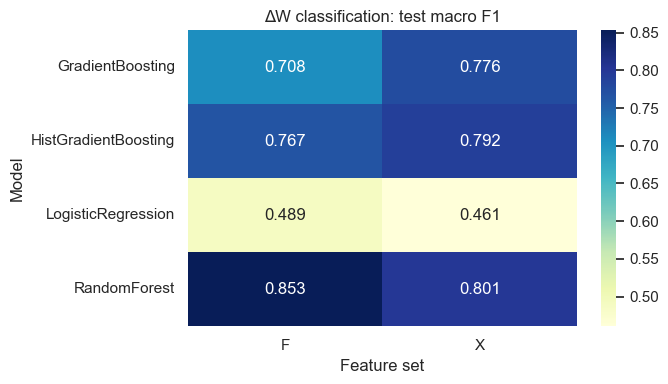

In [9]:
plt.figure(figsize=(7, 4))
sns.heatmap(classification_pivot, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("ΔW classification: test macro F1")
plt.xlabel("Feature set")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

## 2. `ΔDi` regression benchmark

In [11]:
regression_results = []
regression_fits = {}

for fs_name in regression_sets:
    result_df, fit_dict = run_regression_benchmark(df_best, fs_name, "ΔDi", regression_models)
    regression_results.append(result_df)
    regression_fits[fs_name] = fit_dict

regression_summary = pd.concat(regression_results, ignore_index=True)
regression_summary

,feature_set,model,cv_best_score_neg_mae,train_r2,test_r2,train_mae,test_mae,best_params
0,X,GradientBoosting,-0.020933,0.970012,0.936276,0.004687,0.008216,"{'model__learning_rate': 0.03, 'model__max_dep..."
1,X,RandomForest,-0.022667,0.943492,0.907160,0.006701,0.011063,"{'model__max_depth': 8, 'model__max_features':..."
2,X,HistGradientBoosting,-0.022558,0.919827,0.818648,0.007512,0.011412,"{'model__learning_rate': 0.1, 'model__max_dept..."
3,X,Ridge,-0.028059,0.371544,0.072913,0.024102,0.038808,{'model__alpha': 0.1}
4,G,RandomForest,-0.021223,0.948638,0.909617,0.005962,0.010565,"{'model__max_depth': 12, 'model__max_features'..."
5,G,GradientBoosting,-0.018419,0.999450,0.885943,0.000680,0.011625,"{'model__learning_rate': 0.1, 'model__max_dept..."
6,G,HistGradientBoosting,-0.018433,0.988886,0.798550,0.002645,0.014404,"{'model__learning_rate': 0.1, 'model__max_dept..."
7,G,Ridge,-0.028362,0.437437,-0.306577,0.023552,0.044933,{'model__alpha': 1.0}


In [12]:
regression_pivot = regression_summary.pivot(index="model", columns="feature_set", values="test_r2")
regression_pivot

feature_set,G,X
model,,
GradientBoosting,0.885943,0.936276
HistGradientBoosting,0.798550,0.818648
RandomForest,0.909617,0.907160
Ridge,-0.306577,0.072913


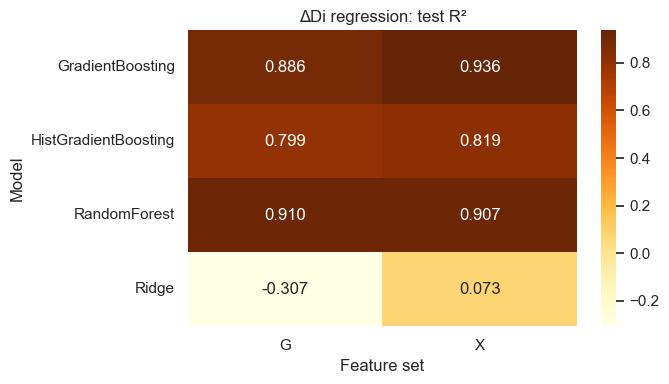

In [13]:
plt.figure(figsize=(7, 4))
sns.heatmap(regression_pivot, annot=True, fmt=".3f", cmap="YlOrBr")
plt.title("ΔDi regression: test R²")
plt.xlabel("Feature set")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

## 5. `RA` regression benchmark

In [17]:
ra_results = []
ra_fits = {}

for fs_name in ra_regression_sets:
    result_df, fit_dict = run_regression_benchmark(df_best, fs_name, "RA", regression_models)
    ra_results.append(result_df)
    ra_fits[fs_name] = fit_dict

ra_summary = pd.concat(ra_results, ignore_index=True)
ra_summary

,feature_set,model,cv_best_score_neg_mae,train_r2,test_r2,train_mae,test_mae,best_params
0,X,GradientBoosting,-0.350948,0.788487,0.574084,0.234760,0.303714,"{'model__learning_rate': 0.03, 'model__max_dep..."
1,X,RandomForest,-0.378441,0.926931,0.548186,0.125217,0.319872,"{'model__max_depth': 8, 'model__max_features':..."
2,X,HistGradientBoosting,-0.379456,0.772589,0.462917,0.241048,0.375300,"{'model__learning_rate': 0.1, 'model__max_dept..."
3,X,Ridge,-0.470961,0.267250,0.139491,0.434633,0.471412,{'model__alpha': 10.0}
4,A,GradientBoosting,-0.342389,0.937869,0.752585,0.122713,0.212670,"{'model__learning_rate': 0.03, 'model__max_dep..."
5,A,RandomForest,-0.326327,0.924426,0.639774,0.131232,0.267912,"{'model__max_depth': 6, 'model__max_features':..."
6,A,HistGradientBoosting,-0.338195,0.969553,0.526122,0.079515,0.306179,"{'model__learning_rate': 0.1, 'model__max_dept..."
7,A,Ridge,-0.431566,0.365699,0.260213,0.399995,0.436773,{'model__alpha': 10.0}
8,B,GradientBoosting,-0.331300,0.939680,0.726282,0.122481,0.227542,"{'model__learning_rate': 0.03, 'model__max_dep..."
9,B,RandomForest,-0.323093,0.887030,0.639587,0.164469,0.264487,"{'model__max_depth': 4, 'model__max_features':..."


In [18]:
ra_pivot = ra_summary.pivot(index="model", columns="feature_set", values="test_r2")
ra_pivot

feature_set,A,B,X
model,,,
GradientBoosting,0.752585,0.726282,0.574084
HistGradientBoosting,0.526122,0.631538,0.462917
RandomForest,0.639774,0.639587,0.548186
Ridge,0.260213,0.331765,0.139491


In [ ]:
plt.figure(figsize=(5, 4))
sns.heatmap(ra_pivot, annot=True, fmt=".3f", cmap="PuBuGn")
plt.title("RA regression: test R²")
plt.xlabel("Feature set")
plt.ylabel("Model")
plt.tight_layout()
plt.show()